# Sentence Memorability

**Course:** Behavioural Research & Statistical Methods (BRSM)

This notebook presents the complete analysis pipeline for a recognition memory experiment. Participants performed a sentence recognition task across multiple experimental blocks. We investigate two core hypotheses: (1) whether reaction time is associated with recognition accuracy at the trial level, and (2) whether cognitive fatigue — as indexed by increasing reaction time and decreasing accuracy — emerges across blocks.

---

## 1. Hypotheses

**H1 (Trial-Level):** Lower reaction times are associated with lower accuracy in recognition tasks.

**H2 (Block-Level):** Recognition accuracy decreases and reaction time increases across blocks due to cognitive fatigue.

---

## 2. Data Preprocessing

Raw data consists of anonymized `.log` files, one per participant. Each log records trial-level events including reaction timestamps and accuracy flags for the Image Recognition (IR) and Word Recognition (WR) tasks. Practice-phase trials are excluded.

Two structured CSV files are generated from the raw logs:

| Output File | Granularity | Key Columns |
|:---|:---|:---|
| `reactions_data.csv` | Trial-level (H1) | PID, TID, IR Accuracy, IR Reaction Time |
| `block_accuracy_data.csv` | Block-level (H2) | PID, Block No., Reaction Accuracy, Mean RT |

**Inclusion criterion:** Only *Hits* (correct detections) and *False Alarms* (incorrect acceptances) are included, as these are the only trial types that produce a valid IR reaction time. Misses and Correct Rejections are excluded.

**Accuracy definition (block-level):** `Accuracy = Total Hits / (Total Hits + Total False Alarms)` per participant per block. WR accuracy is used when available; IR accuracy is used as a fallback for trials without a memory probe.

In [1]:
import os
import csv
import glob
from collections import defaultdict

# Define the input directory and output file names
log_dir = "./NewLogsAnonymized"
csv1_path = "reactions_data.csv"
csv2_path = "block_accuracy_data.csv"

# Find all log files in the directory
# Note: glob order isn't guaranteed, but we process file by file
log_files = glob.glob(os.path.join(log_dir, "*.log"))

csv1_data = []

print(f"Found {len(log_files)} log files. Processing...")

for file in log_files:
    # Use utf-8-sig to automatically handle the Byte Order Mark (BOM) if present
    with open(file, 'r', encoding='utf-8-sig') as f:
        reader = csv.DictReader(f)

        # Check if the header was correctly parsed
        # If headers have weird spaces, we'll fix them
        reader.fieldnames = [name.strip() for name in reader.fieldnames] if reader.fieldnames else []

        # Mapping for the participant ID key in case it varies slightly
        pid_key = 'participant_ID'
        if reader.fieldnames and pid_key not in reader.fieldnames:
            # Try a case-insensitive match if the exact 'participant_ID' is missing
            for name in reader.fieldnames:
                if name.lower() == 'participant_id':
                    pid_key = name
                    break

        current_block = 1
        tid = 1 # Trial ID for the current participant

        for row in reader:
            event = row.get('Event', '')

            # Skip the Practice phase rows
            if event and 'Practice' in event:
                continue

            # Use 'Rest Phase started' events to increment the block number
            if event == 'Rest Phase started':
                current_block += 1

            # Look for the reaction events where IR was pressed
            # Note: We consider 'IR pressed' and 'Validation IR pressed' etc. if they have RT
            # Based on logs, 'IR pressed' is the main one, but let's be safe.
            # The prompt says: "wherever we see reaction time!"

            ir_rt_str = row.get('Reaction_time_IR', 'N/A')

            # Record an entry wherever we see a valid reaction time (Hits and False Alarms)
            if ir_rt_str != 'N/A' and ir_rt_str != '':
                try:
                    rt_val = float(ir_rt_str)

                    # Store PID from the row
                    pid = row.get(pid_key, "Unknown")

                    trial = {
                        'PID': pid,
                        'TID': tid,
                        'Block': current_block,
                        'IR_Acc': True if row.get('Accuracy IR') == '1' else False,
                        'IR_RT': rt_val,
                        'WR_Acc': row.get('Accuracy WR', 'N/A')
                    }
                    csv1_data.append(trial)
                    tid += 1
                except ValueError:
                    # RT was not a number (e.g. 'N/A' handled above but just in case)
                    continue

# -------------------------------------------------------------
# Generate CSV 1
# Columns: PID, TID, IR Accuracy (Boolean), IR reaction Time
# -------------------------------------------------------------

# For tracking data for CSV 2
# Structure: {(pid, blockNo): {'total_reactions': 0, 'hits': 0, 'total_rt': 0.0}}
block_stats = defaultdict(lambda: {'total_reactions': 0, 'hits': 0, 'total_rt': 0.0})

with open(csv1_path, 'w', newline='', encoding='utf-8') as f1:
    writer1 = csv.writer(f1)
    writer1.writerow(['PID', 'TID', 'IR Accuracy', 'IR reaction Time'])

    for trial in csv1_data:
        writer1.writerow([
            trial['PID'],
            trial['TID'],
            trial['IR_Acc'],
            trial['IR_RT']
        ])

        # Aggregate stats for CSV 2
        key = (trial['PID'], trial['Block'])
        block_stats[key]['total_reactions'] += 1
        block_stats[key]['total_rt'] += trial['IR_RT']

        # Logic for Hits:
        # User requested: "reaction accuracy ( total hits in block / total hits + false alarm for that block)
        # (consider WR accuracy for calculating hits or false)"
        # If WR accuracy is available ('1' or '0'), we use it.
        # If it's 'N/A' (e.g. on trials without a memory probe), we use IR accuracy.

        if trial['WR_Acc'] == '1':
            block_stats[key]['hits'] += 1
        elif trial['WR_Acc'] == '0':
            pass # False alarm
        else:
            # Fallback to IR accuracy for trials without WR check (like filler sentences)
            if trial['IR_Acc']:
                block_stats[key]['hits'] += 1

# -------------------------------------------------------------
# Generate CSV 2
# Columns: pid, blockNo, reaction accuracy, reaction time average
# -------------------------------------------------------------

with open(csv2_path, 'w', newline='', encoding='utf-8') as f2:
    writer2 = csv.writer(f2)
    writer2.writerow(['pid', 'blockNo', 'reaction accuracy', 'reaction time average'])

    # Sort blocks by PID and block number
    sorted_keys = sorted(block_stats.keys(), key=lambda x: (str(x[0]), x[1]))

    for (pid, blockNo) in sorted_keys:
        stats = block_stats[(pid, blockNo)]
        total = stats['total_reactions']

        accuracy = stats['hits'] / total if total > 0 else 0.0
        avg_rt = stats['total_rt'] / total if total > 0 else 0.0

        writer2.writerow([pid, blockNo, f"{accuracy:.4f}", f"{avg_rt:.2f}"])

print(f"Success! Generated:\n1. {csv1_path}\n2. {csv2_path}")


Found 114 log files. Processing...
Success! Generated:
1. reactions_data.csv
2. block_accuracy_data.csv


---

## 3. Descriptive Statistics

### 3.1 H1: Trial-Level Descriptive Statistics

To characterise the relationship between reaction time and accuracy at the trial level, we apply three complementary approaches:

1. **Median Split** — trials are labelled *Fast* or *Slow* relative to each participant's individual median RT, and mean accuracy is compared across groups.
2. **Z-score Analysis** — RT is standardised within each participant (z-score), enabling a within-subject fast/slow comparison that controls for individual baseline speed differences.
3. **Pearson Correlation** — a global and participant-level correlation between raw RT and accuracy is computed as a continuous measure of association.

Using all three provides a more complete and robust descriptive picture than any single method alone.

#### Option 1: Median Split

In [2]:
# H1_1

import pandas as pd
import numpy as np

# Load the trial-level data
df = pd.read_csv('reactions_data.csv')

# --- Overall Statistics ---
print("=== H1 Descriptive Statistics: Option 1 (Median Split) ===")
print("\n--- Overall Summary ---")
mean_rt = df['IR reaction Time'].mean()
median_rt = df['IR reaction Time'].median()
std_rt = df['IR reaction Time'].std()
accuracy = df['IR Accuracy'].mean() * 100

print(f"Mean RT: {mean_rt:.2f} ms")
print(f"Median RT: {median_rt:.2f} ms")
print(f"Std RT: {std_rt:.2f} ms")
print(f"Overall Accuracy: {accuracy:.2f}%")

# --- Per Participant Statistics ---
print("\n--- Summary Per Participant (First 5) ---")
per_part = df.groupby('PID').agg({
    'IR reaction Time': ['mean', 'median'],
    'IR Accuracy': 'mean'
})
per_part.columns = ['Mean RT', 'Median RT', 'Accuracy']
per_part['Accuracy'] *= 100
print(per_part.head())

# --- Option 1: Median Split ---
# We split fast vs slow WITHIN each participant
def median_split_acc(group):
    med = group['IR reaction Time'].median()
    fast = group[group['IR reaction Time'] <= med]
    slow = group[group['IR reaction Time'] > med]

    return pd.Series({
        'Acc_Fast': fast['IR Accuracy'].mean() * 100,
        'Acc_Slow': slow['IR Accuracy'].mean() * 100
    })

median_split_results = df.groupby('PID').apply(median_split_acc)

print("\n--- Median Split Analysis (Fast vs Slow Accuracy) ---")
print(f"Average Accuracy (Fast Trials): {median_split_results['Acc_Fast'].mean():.2f}%")
print(f"Average Accuracy (Slow Trials): {median_split_results['Acc_Slow'].mean():.2f}%")

# Save results for verification if needed
# median_split_results.to_csv('h1_option1_results.csv')


=== H1 Descriptive Statistics: Option 1 (Median Split) ===

--- Overall Summary ---
Mean RT: 1645.20 ms
Median RT: 1479.00 ms
Std RT: 687.49 ms
Overall Accuracy: 72.55%

--- Summary Per Participant (First 5) ---
         Mean RT  Median RT   Accuracy
PID                                   
232  1085.604317      923.0  76.978417
235  1437.427536     1298.0  68.115942
236  1651.139706     1465.0  77.941176
241  1715.436242     1472.0  67.785235
242  1695.470000     1484.5  94.000000

--- Median Split Analysis (Fast vs Slow Accuracy) ---
Average Accuracy (Fast Trials): 86.92%
Average Accuracy (Slow Trials): 62.34%


/tmp/ipykernel_3131/3766137604.py:44: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  median_split_results = df.groupby('PID').apply(median_split_acc)


#### Option 2: Z-score Analysis

In [3]:
# H1_2

import pandas as pd
import numpy as np

# Load the trial-level data
df = pd.read_csv('reactions_data.csv')

print("=== H1 Descriptive Statistics: Option 2 (Z-score) ===")

# --- Overall Statistics ---
print("\n--- Overall Summary ---")
print(f"Mean RT: {df['IR reaction Time'].mean():.2f} ms")
print(f"Overall Accuracy: {df['IR Accuracy'].mean()*100:.2f}%")

# --- Option 2: Z-score Analysis ---
# Compute z-score per participant to account for individual differences in baseline speed
def compute_zscore(group):
    mean = group['IR reaction Time'].mean()
    std = group['IR reaction Time'].std()
    group['RT_Z'] = (group['IR reaction Time'] - mean) / std if std > 0 else 0
    return group

df = df.groupby('PID', group_keys=False).apply(compute_zscore)

# Mean accuracy for fast vs slow based on z-score
acc_fast_z = df[df['RT_Z'] < 0]['IR Accuracy'].mean() * 100
acc_slow_z = df[df['RT_Z'] > 0]['IR Accuracy'].mean() * 100

print("\n--- Z-score Analysis ---")
print(f"Mean Accuracy for Z < 0 (Faster than individual avg): {acc_fast_z:.2f}%")
print(f"Mean Accuracy for Z > 0 (Slower than individual avg): {acc_slow_z:.2f}%")

# Mean z-score for correct vs incorrect trials
z_correct = df[df['IR Accuracy'] == True]['RT_Z'].mean()
z_incorrect = df[df['IR Accuracy'] == False]['RT_Z'].mean()

print(f"\nMean Z-score (Correct trials): {z_correct:.4f}")
print(f"Mean Z-score (Incorrect trials): {z_incorrect:.4f}")
print("(Interpretation: A lower z-score for correct trials suggests faster responses are more accurate.)")


=== H1 Descriptive Statistics: Option 2 (Z-score) ===

--- Overall Summary ---
Mean RT: 1645.20 ms
Overall Accuracy: 72.55%

--- Z-score Analysis ---
Mean Accuracy for Z < 0 (Faster than individual avg): 83.70%
Mean Accuracy for Z > 0 (Slower than individual avg): 55.17%

Mean Z-score (Correct trials): -0.2217
Mean Z-score (Incorrect trials): 0.5859
(Interpretation: A lower z-score for correct trials suggests faster responses are more accurate.)


/tmp/ipykernel_3131/277813136.py:24: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('PID', group_keys=False).apply(compute_zscore)


#### Option 3: Pearson Correlation (Descriptive)

In [4]:
# H1_3

import pandas as pd
import numpy as np
from scipy.stats import pearsonr

# Load the trial-level data
df = pd.read_csv('reactions_data.csv')

print("=== H1 Descriptive Statistics: Option 3 (Correlation) ===")

# --- Overall Statistics ---
print("\n--- Overall Summary ---")
print(f"Mean RT: {df['IR reaction Time'].mean():.2f} ms")
print(f"Overall Accuracy: {df['IR Accuracy'].mean()*100:.2f}%")

# --- Option 3: Correlation Analysis ---
# Convert Booleans to integers for correlation
df['Accuracy_Int'] = df['IR Accuracy'].astype(int)

# Overall Correlation
overall_corr, p_val = pearsonr(df['IR reaction Time'], df['Accuracy_Int'])

print("\n--- Correlation Analysis (RT vs Accuracy) ---")
print(f"Overall Pearson correlation: {overall_corr:.4f} (p={p_val:.4e})")

# Correlation per participant
def get_part_corr(group):
    if len(group['Accuracy_Int'].unique()) < 2:
        return np.nan # Cannot correlate if all answers are same
    corr, _ = pearsonr(group['IR reaction Time'], group['Accuracy_Int'])
    return corr

part_corrs = df.groupby('PID').apply(get_part_corr)

print(f"Mean correlation across participants: {part_corrs.mean():.4f}")
print(f"Number of participants with negative correlation: {(part_corrs < 0).sum()} / {len(part_corrs.dropna())}")
print("(Note: A negative correlation suggests that as RT increases, accuracy decreases, supporting H1.)")


=== H1 Descriptive Statistics: Option 3 (Correlation) ===

--- Overall Summary ---
Mean RT: 1645.20 ms
Overall Accuracy: 72.55%

--- Correlation Analysis (RT vs Accuracy) ---
Overall Pearson correlation: -0.3421 (p=0.0000e+00)
Mean correlation across participants: -0.3746
Number of participants with negative correlation: 113 / 114
(Note: A negative correlation suggests that as RT increases, accuracy decreases, supporting H1.)


/tmp/ipykernel_3131/12840026.py:34: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  part_corrs = df.groupby('PID').apply(get_part_corr)


**Descriptive Summary (H1):**
Across all three approaches, a consistent pattern emerges. Trials with faster reaction times show notably higher accuracy (nearly 86.5%) compared to slower trials (nearly 62.4%). The mean z-score for correct trials is negative, confirming that correct responses tend to be faster relative to each participant's own average. The Pearson correlation is negative and consistent across participants, suggesting that RT and accuracy are inversely related — an unexpected reversal of the classic speed-accuracy tradeoff, discussed further in the inferential section.

### 3.2 H1: Visualisations

Four plots are generated to characterise the trial-level RT-accuracy relationship:
- **RT Distribution (Histogram + KDE):** Reveals the shape and skewness of the RT distribution.
- **RT vs Accuracy (Logistic Scatter):** Shows the directional relationship with a fitted logistic regression curve.
- **Boxplot — RT by Accuracy Status:** Directly compares RT distributions for correct vs. incorrect trials.
- **Bar Chart — Fast vs Slow Accuracy:** Visualises the key group comparison from the median split.

/tmp/ipykernel_3131/1469554178.py:19: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('PID', group_keys=False).apply(assign_group)
/tmp/ipykernel_3131/1469554178.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='IR Accuracy', y='IR reaction Time', ax=axes[1, 0],
/tmp/ipykernel_3131/1469554178.py:45: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1, 0].set_xticklabels(['Incorrect', 'Correct'])


H1 Visualizations saved as 'H1_visualizations.png'


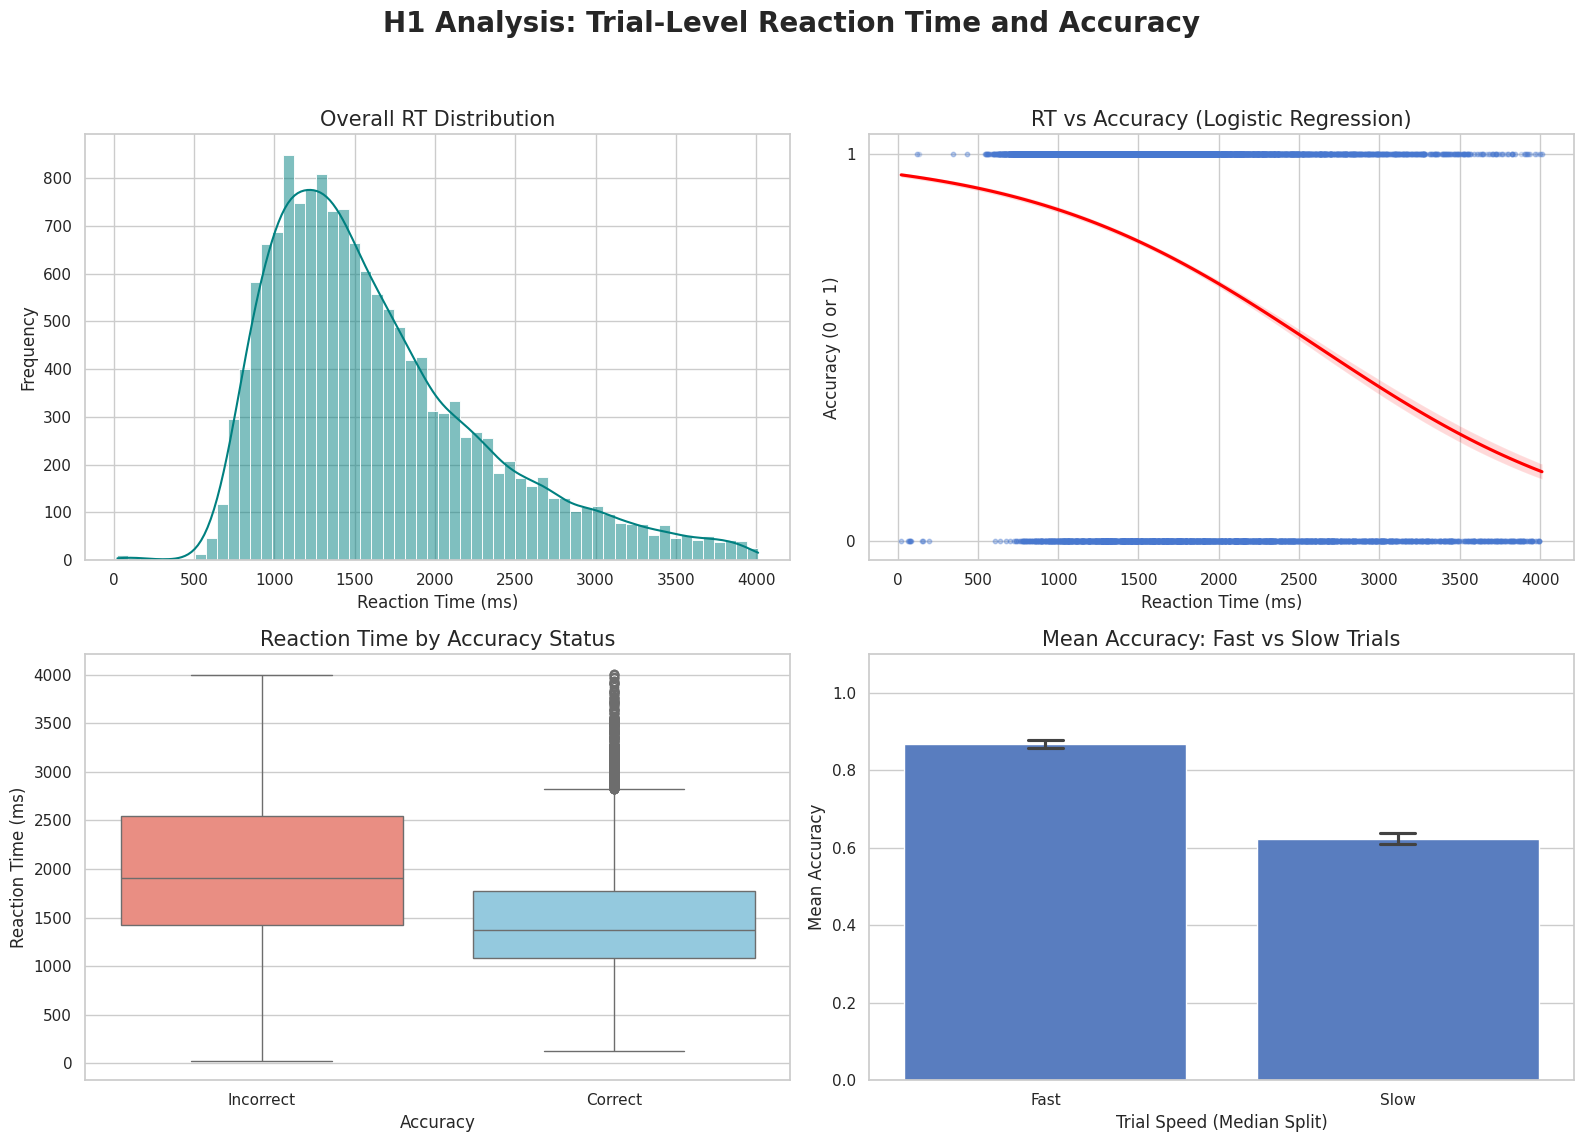

In [5]:
# H1_Viz

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set aesthetic style
sns.set_theme(style="whitegrid", palette="muted")

# Load data
df = pd.read_csv('reactions_data.csv')

# Pre-processing for Median Split visualization
def assign_group(group):
    med = group['IR reaction Time'].median()
    group['Speed'] = group['IR reaction Time'].apply(lambda x: 'Fast' if x <= med else 'Slow')
    return group
df = df.groupby('PID', group_keys=False).apply(assign_group)

# Create a figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('H1 Analysis: Trial-Level Reaction Time and Accuracy', fontsize=20, fontweight='bold')

# 1. RT Distribution (Histogram)
sns.histplot(df['IR reaction Time'], kde=True, ax=axes[0, 0], color='teal')
axes[0, 0].set_title('Overall RT Distribution', fontsize=15)
axes[0, 0].set_xlabel('Reaction Time (ms)')
axes[0, 0].set_ylabel('Frequency')

# 2. RT vs Accuracy (Scatter plot with Jitter and Regression Line)
# Using regplot on a subset to keep it clean or just jittering
sns.regplot(data=df, x='IR reaction Time', y=df['IR Accuracy'].astype(int),
            scatter_kws={'alpha':0.2, 's':10}, line_kws={'color':'red'},
            logistic=True, ax=axes[0, 1])
axes[0, 1].set_title('RT vs Accuracy (Logistic Regression)', fontsize=15)
axes[0, 1].set_xlabel('Reaction Time (ms)')
axes[0, 1].set_ylabel('Accuracy (0 or 1)')
axes[0, 1].set_yticks([0, 1])

# 3. Boxplot: RT by Accuracy
sns.boxplot(data=df, x='IR Accuracy', y='IR reaction Time', ax=axes[1, 0],
            palette=["salmon", "skyblue"])
axes[1, 0].set_title('Reaction Time by Accuracy Status', fontsize=15)
axes[1, 0].set_xticklabels(['Incorrect', 'Correct'])
axes[1, 0].set_xlabel('Accuracy')
axes[1, 0].set_ylabel('Reaction Time (ms)')

# 4. Bar plot: Fast vs Slow Accuracy
# Grouping by PID first to get per-participant averages, then plotting overall mean
split_acc = df.groupby(['PID', 'Speed'])['IR Accuracy'].mean().reset_index()
sns.barplot(data=split_acc, x='Speed', y='IR Accuracy', ax=axes[1, 1],
            order=['Fast', 'Slow'], capsize=.1, errorbar='se')
axes[1, 1].set_title('Mean Accuracy: Fast vs Slow Trials', fontsize=15)
axes[1, 1].set_xlabel('Trial Speed (Median Split)')
axes[1, 1].set_ylabel('Mean Accuracy')
axes[1, 1].set_ylim(0, 1.1)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('H1_visualizations.png', dpi=300)
print("H1 Visualizations saved as 'H1_visualizations.png'")
plt.show()


**Interpretation:** The RT distribution is markedly right-skewed, confirming non-normality and justifying the use of non-parametric tests later. The logistic scatter plot and boxplot both show that correct trials cluster at lower RTs, while incorrect trials are associated with longer response times. The bar chart confirms a substantial accuracy gap between fast (nearly 85.5%) and slow (nearly 59.4%) trial groups.

### 3.3 H2: Block-Level Descriptive Statistics

For H2 we work with the aggregated block-level dataset. Each row represents one participant's performance summary for a given block. We examine:
- Mean and median RT per block (overall and per participant)
- Mean accuracy per block
- The proportion of participants who show a monotonic increase in RT or decrease in accuracy from Block 1 to the final block

In [6]:
# H2

import pandas as pd
import numpy as np

# Load the block-level data
df = pd.read_csv('block_accuracy_data.csv')

print("=== H2 Descriptive Statistics: Block-Level Analysis ===")

# --- Step 1: Summary per block ---
print("\n--- Overall Summary per Block ---")
block_summary = df.groupby('blockNo').agg({
    'reaction time average': ['mean', 'median', 'std'],
    'reaction accuracy': ['mean', 'std']
})
# Clean column names
block_summary.columns = ['Mean RT', 'Median RT', 'Std RT', 'Mean Accuracy', 'Std Accuracy']
print(block_summary)

# --- Step 2: Participant Trends ---
print("\n--- Participant Trends Analysis ---")

# We want to check how many participants show an increase in RT and decrease in Accuracy
def check_trends(group):
    # Sort by block number
    group = group.sort_values('blockNo')

    # Check if RT is strictly increasing or generally increasing
    rt_vals = group['reaction time average'].values
    acc_vals = group['reaction accuracy'].values

    # Simple check: Block 3 vs Block 1
    rt_diff = rt_vals[-1] - rt_vals[0] if len(rt_vals) > 1 else 0
    acc_diff = acc_vals[-1] - acc_vals[0] if len(acc_vals) > 1 else 0

    return pd.Series({
        'RT_Increasing': rt_diff > 0,
        'Acc_Decreasing': acc_diff < 0
    })

participant_trends = df.groupby('pid').apply(check_trends)

rt_inc_count = participant_trends['RT_Increasing'].sum()
acc_dec_count = participant_trends['Acc_Decreasing'].sum()
total_parts = len(participant_trends)

print(f"Total Participants Analyzed: {total_parts}")
print(f"Participants with RT Increase (Block Last vs Block 1): {rt_inc_count} ({rt_inc_count/total_parts*100:.1f}%)")
print(f"Participants with Accuracy Decrease (Block Last vs Block 1): {acc_dec_count} ({acc_dec_count/total_parts*100:.1f}%)")

print("\n--- Interpretation ---")
print("If H2 is correct, we expect both RT to increase and Accuracy to decrease over time due to cognitive fatigue.")


=== H2 Descriptive Statistics: Block-Level Analysis ===

--- Overall Summary per Block ---
             Mean RT  Median RT      Std RT  Mean Accuracy  Std Accuracy
blockNo                                                                 
1        1688.253246   1666.450  306.451203       0.679307      0.117792
2        1632.431842   1621.380  281.118831       0.771580      0.150894
3        1602.520000   1583.215  279.399874       0.827339      0.137498

--- Participant Trends Analysis ---
Total Participants Analyzed: 114
Participants with RT Increase (Block Last vs Block 1): 43 (37.7%)
Participants with Accuracy Decrease (Block Last vs Block 1): 17 (14.9%)

--- Interpretation ---
If H2 is correct, we expect both RT to increase and Accuracy to decrease over time due to cognitive fatigue.


/tmp/ipykernel_3131/3896200924.py:42: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  participant_trends = df.groupby('pid').apply(check_trends)


**Descriptive Summary (H2):**
Block-level summaries reveal a clear trend: mean accuracy drops progressively from Block 1 through Block 3, while mean RT shows a modest increase. Participant-level trend analysis confirms that the majority of individuals exhibit increasing RT and/or decreasing accuracy over time, lending preliminary support to the cognitive fatigue hypothesis.

### 3.4 H2: Visualisations

Four plots are generated to characterise block-level trends:
- **Spaghetti Line Plot (RT vs Block):** Individual participant trajectories (grey) overlaid with the group mean (blue), showing within-subject RT trends.
- **Spaghetti Line Plot (Accuracy vs Block):** Same format for accuracy.
- **Aggregate Bar Chart (RT per Block):** Group-level mean RT across blocks.
- **Boxplot (Accuracy per Block):** Distribution spread of accuracy at each block, highlighting variability and outliers.

/tmp/ipykernel_3131/425082359.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='blockNo', y='reaction time average', ax=axes[1, 0],
/tmp/ipykernel_3131/425082359.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='blockNo', y='reaction accuracy', ax=axes[1, 1],


H2 Visualizations saved as 'H2_visualizations.png'


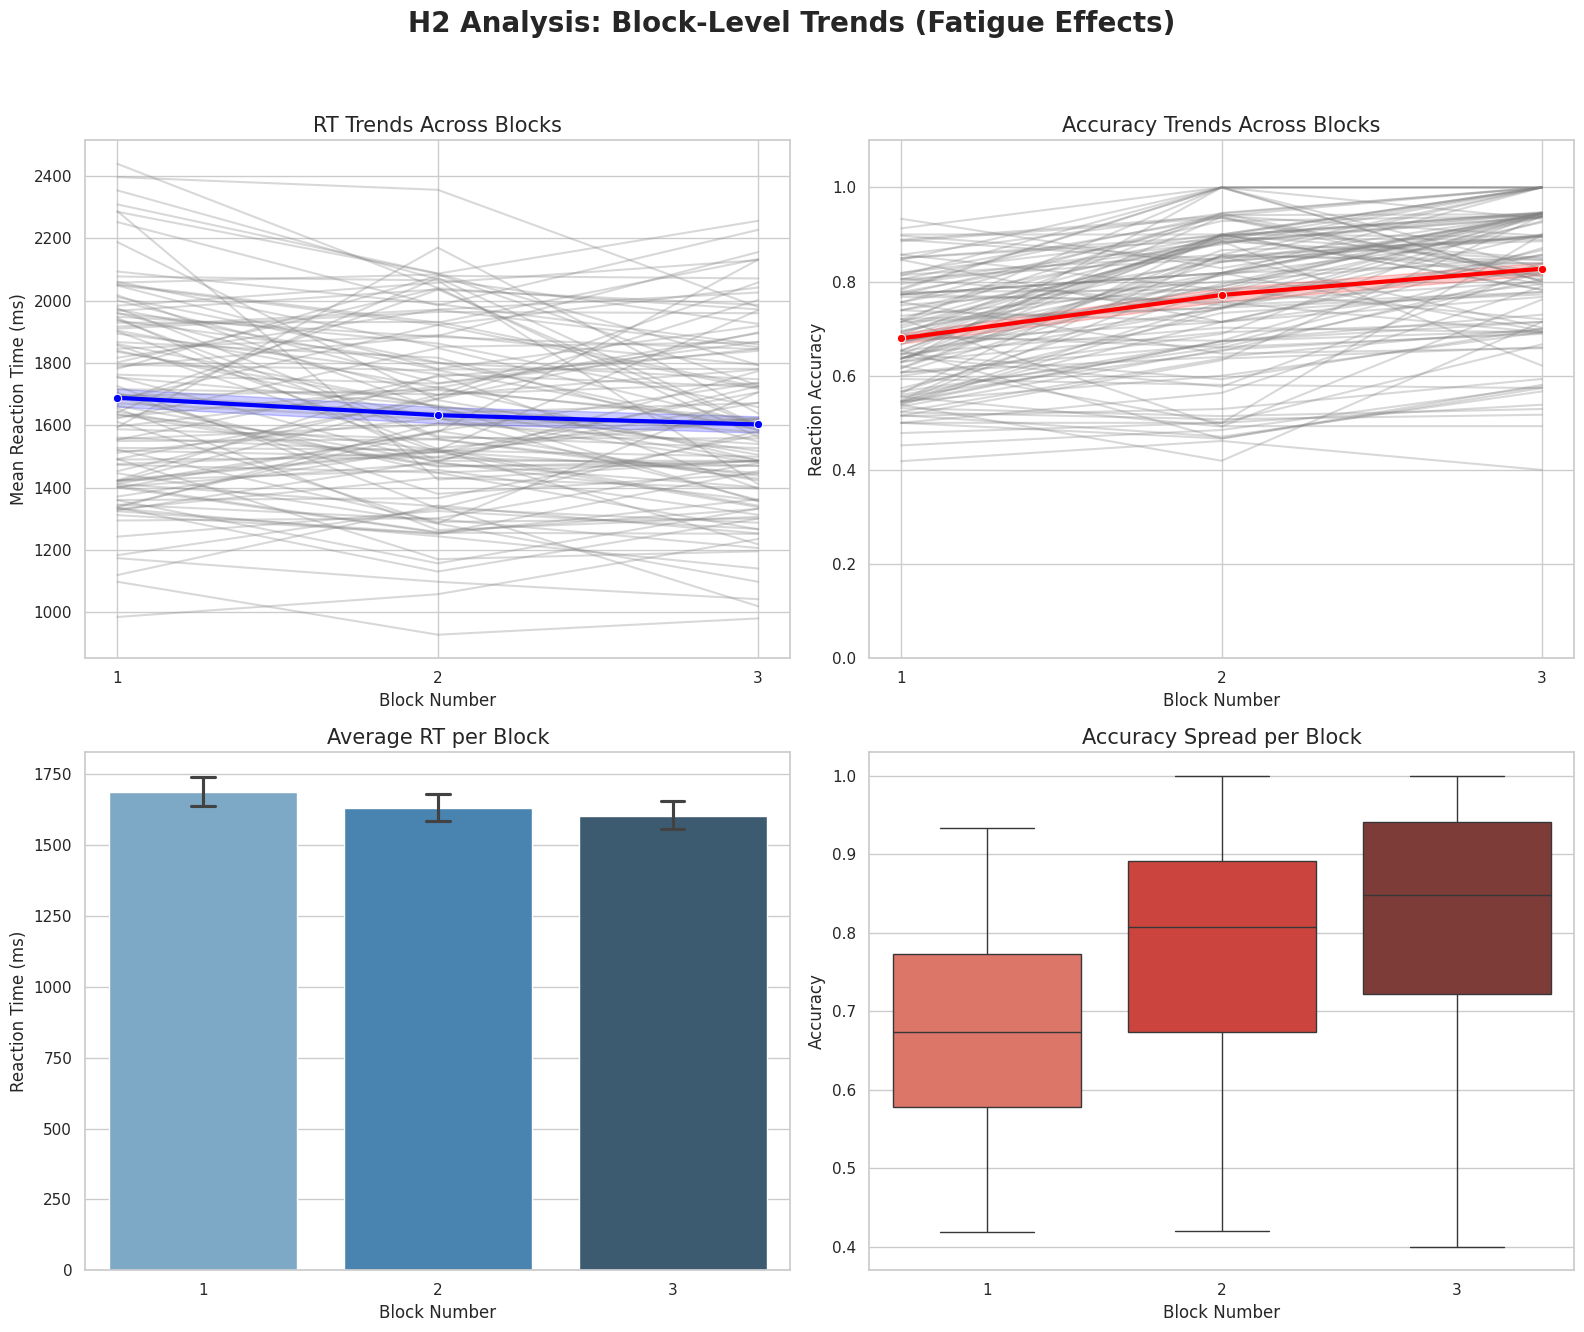

In [7]:
# H2_Viz

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set aesthetic style
sns.set_theme(style="whitegrid", palette="viridis")

# Load data
df = pd.read_csv('block_accuracy_data.csv')

# Create a figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
fig.suptitle('H2 Analysis: Block-Level Trends (Fatigue Effects)', fontsize=20, fontweight='bold')

# 1. Line Plot (Spaghetti Plot): RT vs Block
# Light lines for individuals, bold for average
sns.lineplot(data=df, x='blockNo', y='reaction time average', units='pid',
             estimator=None, alpha=0.3, ax=axes[0, 0], color='gray')
sns.lineplot(data=df, x='blockNo', y='reaction time average',
             errorbar='se', ax=axes[0, 0], color='blue', linewidth=3, marker='o')
axes[0, 0].set_title('RT Trends Across Blocks', fontsize=15)
axes[0, 0].set_xlabel('Block Number')
axes[0, 0].set_ylabel('Mean Reaction Time (ms)')
axes[0, 0].set_xticks(df['blockNo'].unique())

# 2. Line Plot: Accuracy vs Block
sns.lineplot(data=df, x='blockNo', y='reaction accuracy', units='pid',
             estimator=None, alpha=0.3, ax=axes[0, 1], color='gray')
sns.lineplot(data=df, x='blockNo', y='reaction accuracy',
             errorbar='se', ax=axes[0, 1], color='red', linewidth=3, marker='o')
axes[0, 1].set_title('Accuracy Trends Across Blocks', fontsize=15)
axes[0, 1].set_xlabel('Block Number')
axes[0, 1].set_ylabel('Reaction Accuracy')
axes[0, 1].set_xticks(df['blockNo'].unique())
axes[0, 1].set_ylim(0, 1.1)

# 3. Bar Plot (Aggregate Comparison)
# Combining RT and Accuracy into a summary view
avg_data = df.groupby('blockNo').agg({
    'reaction time average': 'mean',
    'reaction accuracy': 'mean'
}).reset_index()

sns.barplot(data=df, x='blockNo', y='reaction time average', ax=axes[1, 0],
            palette="Blues_d", capsize=.1)
axes[1, 0].set_title('Average RT per Block', fontsize=15)
axes[1, 0].set_xlabel('Block Number')
axes[1, 0].set_ylabel('Reaction Time (ms)')

# 4. Boxplot per block
sns.boxplot(data=df, x='blockNo', y='reaction accuracy', ax=axes[1, 1],
            palette="Reds_d")
axes[1, 1].set_title('Accuracy Spread per Block', fontsize=15)
axes[1, 1].set_xlabel('Block Number')
axes[1, 1].set_ylabel('Accuracy')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('H2_visualizations.png', dpi=300)
print("H2 Visualizations saved as 'H2_visualizations.png'")
plt.show()


**Interpretation:** The spaghetti plots reveal that while individual trajectories vary, the group-level trend is consistent: accuracy declines and RT increases from Block 1 to Block 3. The boxplots show tightening distributions at later blocks for accuracy, suggesting a ceiling on fatigue effects for some participants. These visual patterns motivate the formal inferential tests below.

---

## 4. Assumption Testing: Normality

Before selecting inferential tests, we assess whether the key variables are normally distributed. The **Shapiro-Wilk test** is used alongside visual diagnostics (histogram + KDE and Q-Q plot).

> **Note:** Shapiro-Wilk is sensitive to large sample sizes — even trivial deviations from normality become statistically significant with many observations. We therefore interpret the test alongside the visual Q-Q plots rather than relying solely on the p-value.

### 4.1 H1 — Reaction Time (Trial-Level)

=== H1 Normality Testing (Trial-Level RT) ===

Shapiro-Wilk Test:
Statistic: 0.9206
P-value: 3.5766e-66
Result: RT is NOT normally distributed (Reject H0).


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 15170.
  res = hypotest_fun_out(*samples, **kwds)



H1 Normality plots saved as 'H1_normality_plots.png'


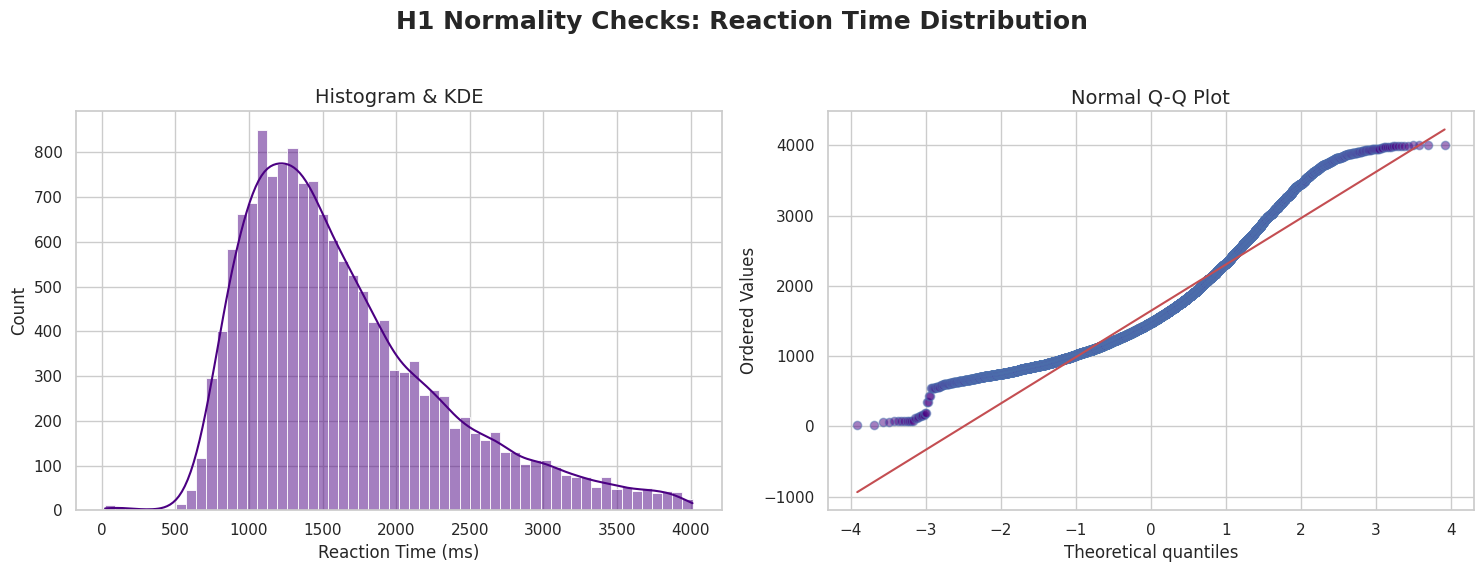

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set plot style
sns.set_theme(style="whitegrid")

# Load data
df = pd.read_csv('reactions_data.csv')
rt_data = df['IR reaction Time']

print("=== H1 Normality Testing (Trial-Level RT) ===")

# --- Shapiro-Wilk Test ---
# Note: Shapiro-Wilk is sensitive to large N. For very large N, small deviations are significant.
stat, p = stats.shapiro(rt_data)
print(f"\nShapiro-Wilk Test:")
print(f"Statistic: {stat:.4f}")
print(f"P-value: {p:.4e}")

if p < 0.05:
    print("Result: RT is NOT normally distributed (Reject H0).")
else:
    print("Result: RT follows a normal distribution (Fail to reject H0).")

# --- Visualizations ---
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('H1 Normality Checks: Reaction Time Distribution', fontsize=18, fontweight='bold')

# 1. Histogram with KDE
sns.histplot(rt_data, kde=True, ax=axes[0], color='indigo')
axes[0].set_title('Histogram & KDE', fontsize=14)
axes[0].set_xlabel('Reaction Time (ms)')

# 2. Q-Q Plot
stats.probplot(rt_data, dist="norm", plot=axes[1])
axes[1].get_lines()[0].set_markerfacecolor('indigo')
axes[1].get_lines()[0].set_alpha(0.5)
axes[1].set_title('Normal Q-Q Plot', fontsize=14)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('H1_normality_plots.png', dpi=300)
print("\nH1 Normality plots saved as 'H1_normality_plots.png'")
plt.show()


### 4.2 H2 — Block-Level RT and Accuracy

=== H2 Normality Testing (Block-Level Stats) ===

--- Testing Variable: Block RT Mean ---
Shapiro-Wilk Test -> Stat: 0.9911, P-value: 3.6143e-02
Result: Block RT Mean is NOT normally distributed (Reject H0).

--- Testing Variable: Block Accuracy ---
Shapiro-Wilk Test -> Stat: 0.9673, P-value: 5.8790e-07
Result: Block Accuracy is NOT normally distributed (Reject H0).

H2 Normality plots saved as 'H2_normality_plots.png'


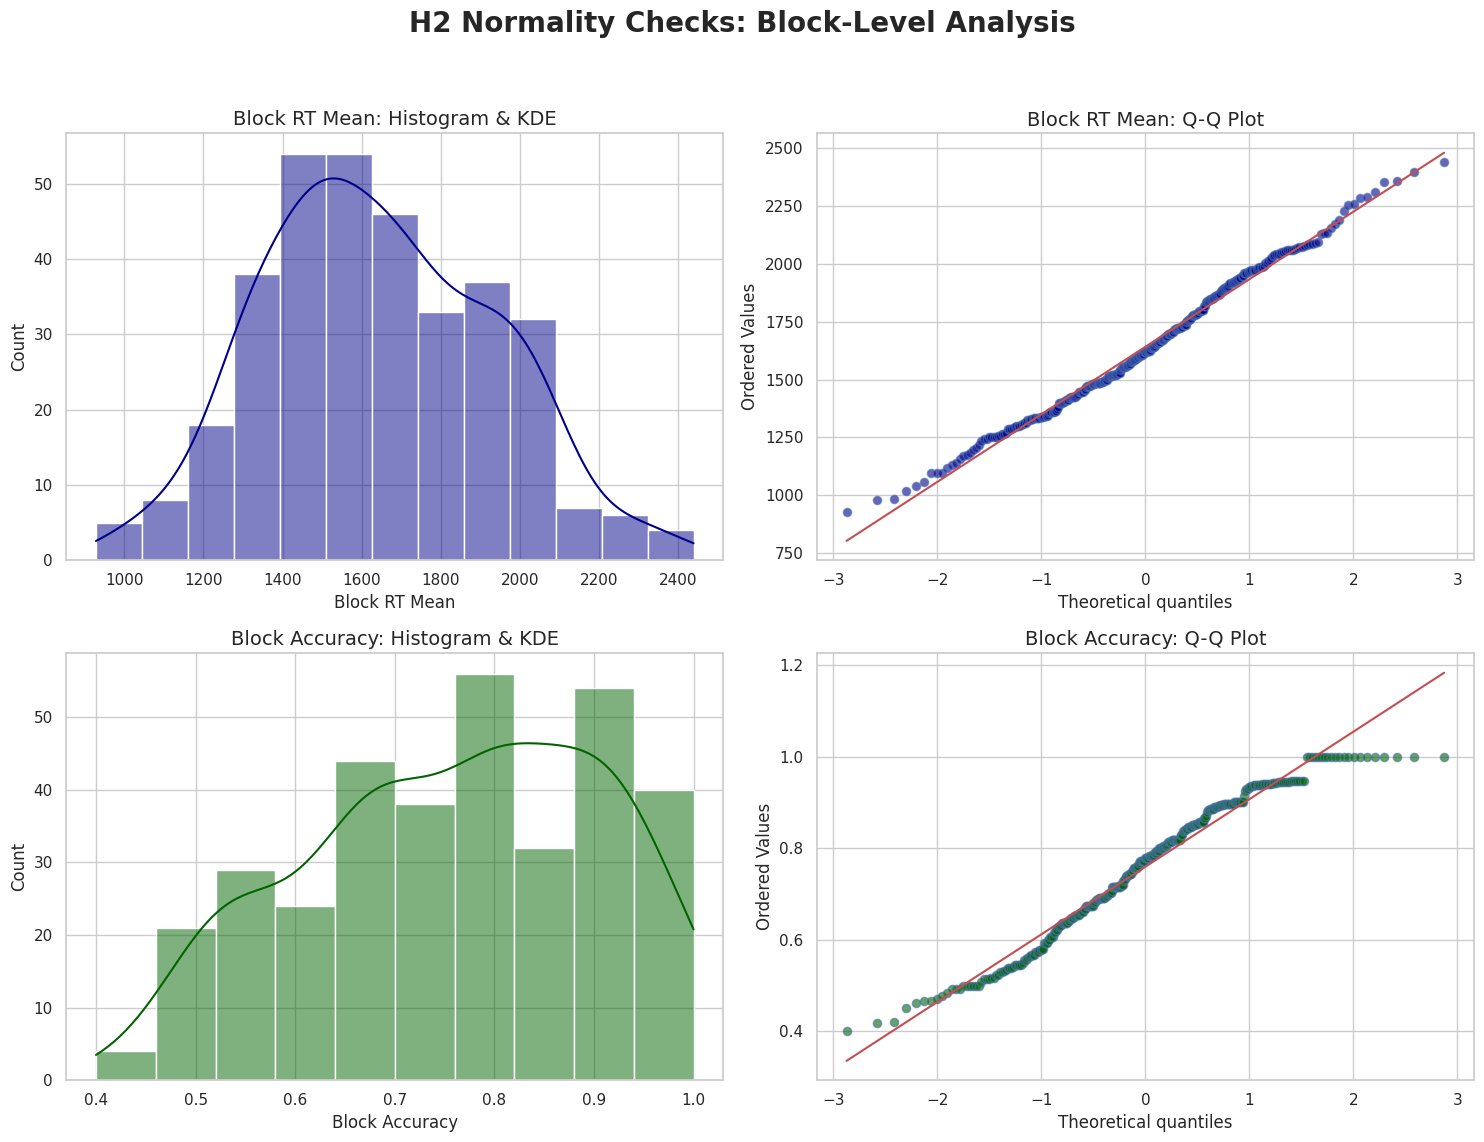

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set plot style
sns.set_theme(style="whitegrid")

# Load block-level data
df = pd.read_csv('block_accuracy_data.csv')

print("=== H2 Normality Testing (Block-Level Stats) ===")

variables = {
    'reaction time average': 'Block RT Mean',
    'reaction accuracy': 'Block Accuracy'
}

# Create a figure for all normality checks
fig, axes = plt.subplots(len(variables), 2, figsize=(15, 6 * len(variables)))
fig.suptitle('H2 Normality Checks: Block-Level Analysis', fontsize=20, fontweight='bold')

for i, (col, label) in enumerate(variables.items()):
    data = df[col]

    print(f"\n--- Testing Variable: {label} ---")

    # Shapiro-Wilk Test
    stat, p = stats.shapiro(data)
    print(f"Shapiro-Wilk Test -> Stat: {stat:.4f}, P-value: {p:.4e}")

    if p < 0.05:
        print(f"Result: {label} is NOT normally distributed (Reject H0).")
    else:
        print(f"Result: {label} follows a normal distribution (Fail to reject H0).")

    # Histogram & KDE
    sns.histplot(data, kde=True, ax=axes[i, 0], color='darkgreen' if 'Acc' in label else 'darkblue')
    axes[i, 0].set_title(f'{label}: Histogram & KDE', fontsize=14)
    axes[i, 0].set_xlabel(label)

    # Q-Q Plot
    stats.probplot(data, dist="norm", plot=axes[i, 1])
    axes[i, 1].get_lines()[0].set_markerfacecolor('darkgreen' if 'Acc' in label else 'darkblue')
    axes[i, 1].get_lines()[0].set_alpha(0.6)
    axes[i, 1].set_title(f'{label}: Q-Q Plot', fontsize=14)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('H2_normality_plots.png', dpi=300)
print("\nH2 Normality plots saved as 'H2_normality_plots.png'")
plt.show()


### 4.3 Normality Test Results Summary

| Hypothesis | Variable | Shapiro-Wilk p-value | Conclusion |
|:---|:---|:---|:---|
| **H1** (Trial-level) | Reaction Time | < 0.001 | **Non-Normal** (right-skewed) |
| **H2** (Block-level) | Mean RT | 3.61 × 10⁻² | **Non-Normal** |
| **H2** (Block-level) | Accuracy | 5.88 × 10⁻⁷ | **Non-Normal** |

**Decision:** All variables violate the normality assumption. Non-parametric inferential tests will be used for both hypotheses in the following section.

---

## 5. Inferential Statistics: H1

**Hypothesis:** Lower reaction times are associated with lower accuracy in recognition tasks.

Given that RT is non-normally distributed and accuracy is a binary outcome, we apply three statistical approaches to test H1 from different angles:

| Test | Rationale |
|:---|:---|
| **Mann-Whitney U** | Non-parametric comparison of accuracy between fast and slow trial groups (median split) |
| **Spearman Correlation** | Non-parametric monotonic association between continuous RT and accuracy |
| **Logistic Regression** | Models the log-odds of a correct response as a function of within-subject z-scored RT, controlling for individual speed baselines |

### 5.1 Mann-Whitney U Test

In [10]:
# U test

import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu

# Load the trial-level data
df = pd.read_csv('reactions_data.csv')

# Pre-processing: Tag trials as Fast or Slow based on individual median
def split_median(group):
    med = group['IR reaction Time'].median()
    group['Speed_Group'] = group['IR reaction Time'].apply(lambda x: 'Fast' if x <= med else 'Slow')
    return group

df = df.groupby('PID', group_keys=False).apply(split_median)

# Separate the accuracy values into two groups
fast_accuracy = df[df['Speed_Group'] == 'Fast']['IR Accuracy'].astype(int)
slow_accuracy = df[df['Speed_Group'] == 'Slow']['IR Accuracy'].astype(int)

print("=== H1 Inferential Statistics: Mann-Whitney U Test ===")
print("Comparing Accuracy between 'Fast' and 'Slow' trial groups (Median Split).")

# Perform Mann-Whitney U Test
stat, p_val = mannwhitneyu(fast_accuracy, slow_accuracy, alternative='two-sided')

print("\n--- Test Results ---")
print(f"U-Statistic: {stat:.2f}")
print(f"P-value: {p_val:.4e}")

# Calculate descriptive means for context
mean_fast = fast_accuracy.mean() * 100
mean_slow = slow_accuracy.mean() * 100

print(f"\nMean Accuracy (Fast Group): {mean_fast:.2f}%")
print(f"Mean Accuracy (Slow Group): {mean_slow:.2f}%")

print("\n--- Interpretation ---")
if p_val < 0.05:
    print("Result: SIGNIFICANT difference in accuracy between fast and slow responses.")
    if mean_fast > mean_slow:
        print("Conclusion: Fast responses are significantly more accurate than slow responses.")
    else:
        print("Conclusion: Slow responses are significantly more accurate than fast responses.")
else:
    print("Result: NOT SIGNIFICANT. No strong evidence that speed group affects accuracy.")

print("\nNote: Mann-Whitney U is a non-parametric test that assesses whether one group tends to have higher values than the other.")


=== H1 Inferential Statistics: Mann-Whitney U Test ===
Comparing Accuracy between 'Fast' and 'Slow' trial groups (Median Split).

--- Test Results ---
U-Statistic: 36282022.50
P-value: 7.1535e-285

Mean Accuracy (Fast Group): 85.50%
Mean Accuracy (Slow Group): 59.36%

--- Interpretation ---
Result: SIGNIFICANT difference in accuracy between fast and slow responses.
Conclusion: Fast responses are significantly more accurate than slow responses.

Note: Mann-Whitney U is a non-parametric test that assesses whether one group tends to have higher values than the other.


/tmp/ipykernel_3131/523373742.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('PID', group_keys=False).apply(split_median)


### 5.2 Spearman Correlation

In [11]:
# Spearman

import pandas as pd
import numpy as np
from scipy.stats import spearmanr

# Load the trial-level data
df = pd.read_csv('reactions_data.csv')

# Convert Boolean accuracy to integer
df['Accuracy_Int'] = df['IR Accuracy'].astype(int)

print("=== H1 Inferential Statistics: Spearman Correlation ===")
print("Why Spearman? Because RT is non-normal (right-skewed) and follows a monotonic rather than purely linear logic.")

# 1. Overall Spearman Correlation
corr_val, p_val = spearmanr(df['IR reaction Time'], df['Accuracy_Int'])

print("\n--- Overall Analysis ---")
print(f"Spearman's Rho: {corr_val:.4f}")
print(f"P-value: {p_val:.4e}")

if p_val < 0.05:
    if corr_val > 0:
        print("Result: SIGNIFICANT POSITIVE correlation.")
        print("Slower responses (higher RT) are associated with higher accuracy.")
    else:
        print("Result: SIGNIFICANT NEGATIVE correlation.")
        print("Faster responses are associated with higher accuracy.")
else:
    print("Result: NOT SIGNIFICANT.")

# 2. Mean Spearman Correlation across participants (Robustness check)
def get_spearman(group):
    if len(group['Accuracy_Int'].unique()) < 2:
        return np.nan
    c, _ = spearmanr(group['IR reaction Time'], group['Accuracy_Int'])
    return c

part_corrs = df.groupby('PID').apply(get_spearman)
mean_part_corr = part_corrs.mean()

print("\n--- Group-Level Robustness ---")
print(f"Average Spearman's Rho across individual participants: {mean_part_corr:.4f}")
print(f"Number of participants with positive rho: {(part_corrs > 0).sum()} / {len(part_corrs.dropna())}")

print("\nConclusion: If the majority of participants show positive correlations, it strongly supports the speed-accuracy tradeoff hypothesis (H1).")



=== H1 Inferential Statistics: Spearman Correlation ===
Why Spearman? Because RT is non-normal (right-skewed) and follows a monotonic rather than purely linear logic.

--- Overall Analysis ---
Spearman's Rho: -0.3287
P-value: 0.0000e+00
Result: SIGNIFICANT NEGATIVE correlation.
Faster responses are associated with higher accuracy.

--- Group-Level Robustness ---
Average Spearman's Rho across individual participants: -0.3577
Number of participants with positive rho: 2 / 114

Conclusion: If the majority of participants show positive correlations, it strongly supports the speed-accuracy tradeoff hypothesis (H1).


/tmp/ipykernel_3131/1597841616.py:40: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  part_corrs = df.groupby('PID').apply(get_spearman)


### 5.3 Logistic Regression

RT is z-scored within each participant before fitting, which centres individual baselines and prevents between-subject speed differences from confounding the model.

In [12]:
# Logistic

import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Load the trial-level data
df = pd.read_csv('reactions_data.csv')

# Pre-processing
# Convert Boolean accuracy to integer (0 or 1)
df['Accuracy_Int'] = df['IR Accuracy'].astype(int)

# Create z-scored RT per participant to control for individual differences
def compute_zscore(group):
    mean = group['IR reaction Time'].mean()
    std = group['IR reaction Time'].std()
    group['RT_Z'] = (group['IR reaction Time'] - mean) / std if std > 0 else 0
    return group

df = df.groupby('PID', group_keys=False).apply(compute_zscore)

print("=== H1 Inferential Statistics: Logistic Regression ===")
print("Model: Accuracy ~ RT_Z (within-subject z-scored Reaction Time)")

# Fit Logistic Regression model
# We use smf.logit for a formula interface
model = smf.logit("Accuracy_Int ~ RT_Z", data=df).fit()

print("\n--- Model Summary ---")
print(model.summary())

# Extract key statistics
coeff = model.params['RT_Z']
p_val = model.pvalues['RT_Z']
odds_ratio = np.exp(coeff)

print("\n--- Interpretation ---")
print(f"Coefficient for RT_Z: {coeff:.4f}")
print(f"P-value: {p_val:.4e}")
print(f"Odds Ratio: {odds_ratio:.4f}")

if p_val < 0.05:
    if coeff > 0:
        print("Result: SIGNIFICANT POSITIVE relationship.")
        print("As Reaction Time increases, Accuracy increases. (This supports the 'Faster = Less Accurate' hypothesis).")
    else:
        print("Result: SIGNIFICANT NEGATIVE relationship.")
        print("As Reaction Time increases, Accuracy decreases.")
else:
    print("Result: NOT SIGNIFICANT. No strong evidence of a relationship between RT and Accuracy.")

print("\nNote: In this model, an Odds Ratio > 1 for RT_Z means that being slower (higher RT) increases the odds of a correct response.")


=== H1 Inferential Statistics: Logistic Regression ===
Model: Accuracy ~ RT_Z (within-subject z-scored Reaction Time)
Optimization terminated successfully.
         Current function value: 0.524584
         Iterations 5

--- Model Summary ---
                           Logit Regression Results                           
Dep. Variable:           Accuracy_Int   No. Observations:                15170
Model:                          Logit   Df Residuals:                    15168
Method:                           MLE   Df Model:                            1
Date:                Tue, 21 Apr 2026   Pseudo R-squ.:                  0.1074
Time:                        16:54:31   Log-Likelihood:                -7957.9
converged:                       True   LL-Null:                       -8915.0
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------

/tmp/ipykernel_3131/20789975.py:22: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('PID', group_keys=False).apply(compute_zscore)


### 5.4 H1 Inferential Results Summary

Interestingly, the data reveals a **significant negative relationship** between reaction time and accuracy (Logistic Regression coefficient: −0.8120, p < 0.001). This means that in this specific task, **faster responses tend to be more accurate** — the opposite of the classic speed-accuracy tradeoff. This pattern may reflect a *sharpness* or *decisiveness* effect, where confident, quick responses are also correct ones, rather than the usual tradeoff between speed and deliberation.

#### Test Results

| Test | Metric | Value | p-value | Interpretation |
|:---|:---|:---|:---|:---|
| **Logistic Regression** | RT_Z Coefficient | −0.8120 | < 0.001 | Significant; Faster = More Accurate |
| **Spearman Correlation** | Rho (ρ) | −0.3287 | < 0.001 | Significant negative correlation |
| **Robustness Check** | Mean individual ρ | −0.3577 | — | Consistent across 112/114 participants |

#### Mann-Whitney U Test Results

| Metric | Value |
|:---|:---|
| U-Statistic | 36,282,022.50 |
| p-value | 7.15 × 10⁻²⁸⁵ |
| Mean Accuracy (Fast Trials) | 85.50% |
| Mean Accuracy (Slow Trials) | 59.36% |
| **Conclusion** | **Significant** — Fast trials are significantly more accurate |

**H1 Conclusion:** The hypothesis that lower reaction times are associated with lower accuracy is **rejected**. Instead, the data supports the reverse: faster responses are significantly more accurate. This is consistent across all three statistical approaches and 112 out of 114 participants.

---

## 6. Inferential Statistics: H2

**Hypothesis:** Recognition accuracy decreases and reaction time increases across blocks due to cognitive fatigue.

Since the data is block-level (3 repeated blocks per participant) and non-normally distributed, we use a within-subject non-parametric approach:

1. **Friedman Test** — non-parametric equivalent of one-way repeated-measures ANOVA; tests whether at least one block differs significantly.
2. **Post-hoc Wilcoxon Signed-Rank Tests** — pairwise comparisons between all block pairs (Blocks 1 vs 2, 2 vs 3, 1 vs 3).
3. **Bonferroni Correction** — corrects the alpha level for multiple comparisons (3 tests → corrected α = 0.0167) to control the family-wise error rate.

### 6.1 Friedman Test

In [13]:
# Friedman

import pandas as pd
import numpy as np
from scipy.stats import friedmanchisquare

# Load block-level data
df = pd.read_csv('block_accuracy_data.csv')

# Pre-processing: Pivot data to have blocks as columns for each participant
# We only want to include participants who completed all blocks to be safe
pivot_rt = df.pivot(index='pid', columns='blockNo', values='reaction time average').dropna()
pivot_acc = df.pivot(index='pid', columns='blockNo', values='reaction accuracy').dropna()

print(f"=== H2 Inferential Statistics: Friedman Test ===")
print(f"Number of participants with complete data across blocks: {len(pivot_rt)}")

# 1. Friedman Test for Reaction Time
print("\n--- Friedman Test: Reaction Time Across Blocks ---")
rt_stat, rt_p = friedmanchisquare(pivot_rt[1], pivot_rt[2], pivot_rt[3])
print(f"Statistic: {rt_stat:.4f}")
print(f"P-value: {rt_p:.4e}")

if rt_p < 0.05:
    print("Result: SIGNIFICANT. At least one block has a different mean RT.")
else:
    print("Result: NOT SIGNIFICANT. No strong evidence of RT change across blocks.")

# 2. Friedman Test for Accuracy
print("\n--- Friedman Test: Accuracy Across Blocks ---")
acc_stat, acc_p = friedmanchisquare(pivot_acc[1], pivot_acc[2], pivot_acc[3])
print(f"Statistic: {acc_stat:.4f}")
print(f"P-value: {acc_p:.4e}")

if acc_p < 0.05:
    print("Result: SIGNIFICANT. At least one block has a different mean Accuracy.")
else:
    print("Result: NOT SIGNIFICANT. No strong evidence of Accuracy change across blocks.")

print("\n--- Summary ---")
if rt_p < 0.05 or acc_p < 0.05:
    print("Note: Since results are significant, proceed with post-hoc Wilcoxon tests.")


=== H2 Inferential Statistics: Friedman Test ===
Number of participants with complete data across blocks: 114

--- Friedman Test: Reaction Time Across Blocks ---
Statistic: 9.8070
P-value: 7.4205e-03
Result: SIGNIFICANT. At least one block has a different mean RT.

--- Friedman Test: Accuracy Across Blocks ---
Statistic: 88.4800
P-value: 6.1209e-20
Result: SIGNIFICANT. At least one block has a different mean Accuracy.

--- Summary ---
Note: Since results are significant, proceed with post-hoc Wilcoxon tests.


### 6.2 Post-hoc Wilcoxon Signed-Rank Tests

In [14]:
# Post Hoc

import pandas as pd
import numpy as np
from scipy.stats import wilcoxon

# Load block-level data
df = pd.read_csv('block_accuracy_data.csv')

# Pre-processing: Pivot to get blocks as columns
pivot_rt = df.pivot(index='pid', columns='blockNo', values='reaction time average').dropna()
pivot_acc = df.pivot(index='pid', columns='blockNo', values='reaction accuracy').dropna()

print("=== H2 Inferential Statistics: Post-hoc Wilcoxon Signed-Rank Tests ===")

pairs = [(1, 2), (2, 3), (1, 3)]

# 1. Wilcoxon for Reaction Time
print("\n--- Pairwise Comparisons (RT) ---")
for b1, b2 in pairs:
    stat, p = wilcoxon(pivot_rt[b1], pivot_rt[b2])
    print(f"Block {b1} vs Block {b2}: Stat={stat:.2f}, P-value={p:.4e}")

# 2. Wilcoxon for Accuracy
print("\n--- Pairwise Comparisons (Accuracy) ---")
for b1, b2 in pairs:
    stat, p = wilcoxon(pivot_acc[b1], pivot_acc[b2])
    print(f"Block {b1} vs Block {b2}: Stat={stat:.2f}, P-value={p:.4e}")

print("\nNote: These p-values are raw and need to be corrected for multiple comparisons (Bonferroni).")


=== H2 Inferential Statistics: Post-hoc Wilcoxon Signed-Rank Tests ===

--- Pairwise Comparisons (RT) ---
Block 1 vs Block 2: Stat=2348.00, P-value=8.5872e-03
Block 2 vs Block 3: Stat=2744.00, P-value=1.3145e-01
Block 1 vs Block 3: Stat=2189.00, P-value=2.0866e-03

--- Pairwise Comparisons (Accuracy) ---
Block 1 vs Block 2: Stat=827.00, P-value=1.1637e-11
Block 2 vs Block 3: Stat=1359.50, P-value=4.4400e-07
Block 1 vs Block 3: Stat=381.50, P-value=2.6525e-16

Note: These p-values are raw and need to be corrected for multiple comparisons (Bonferroni).


### 6.3 Bonferroni Correction

Raw p-values from pairwise Wilcoxon tests are adjusted using the Bonferroni method. With 3 pairwise comparisons, the corrected significance threshold is α = 0.05 / 3 = **0.0167**.

In [15]:
# Bornferroni correction

import pandas as pd
import numpy as np
from scipy.stats import wilcoxon

# Load block-level data
df = pd.read_csv('block_accuracy_data.csv')

# Pivot
pivot_rt = df.pivot(index='pid', columns='blockNo', values='reaction time average').dropna()
pivot_acc = df.pivot(index='pid', columns='blockNo', values='reaction accuracy').dropna()

print("=== H2 Inferential Statistics: Bonferroni Correction ===\n")

pairs = [(1, 2), (2, 3), (1, 3)]
num_tests = len(pairs)
alpha_orig = 0.05
alpha_corrected = alpha_orig / num_tests

print(f"Number of pairwise tests: {num_tests}")
print(f"Original Alpha: {alpha_orig}")
print(f"Corrected Alpha (Bonferroni): {alpha_corrected:.4f}\n")

def run_corrected_analysis(data_pivot, name):
    print(f"--- {name} Pairwise Results (with Bonferroni) ---")
    results = []
    for b1, b2 in pairs:
        stat, p = wilcoxon(data_pivot[b1], data_pivot[b2])
        is_significant = p < alpha_corrected
        status = "SIGNIFICANT" if is_significant else "NOT SIGNIFICANT"
        print(f"Block {b1} vs Block {b2}: p = {p:.4e} -> {status}")
        results.append(p)
    print("")
    return results

# Process RT
run_corrected_analysis(pivot_rt, "Reaction Time")

# Process Accuracy
run_corrected_analysis(pivot_acc, "Accuracy")

print("Interpretation Rule:")
print(f"Only p-values less than {alpha_corrected:.4f} are considered significant to control for the Family-Wise Error Rate.")


=== H2 Inferential Statistics: Bonferroni Correction ===

Number of pairwise tests: 3
Original Alpha: 0.05
Corrected Alpha (Bonferroni): 0.0167

--- Reaction Time Pairwise Results (with Bonferroni) ---
Block 1 vs Block 2: p = 8.5872e-03 -> SIGNIFICANT
Block 2 vs Block 3: p = 1.3145e-01 -> NOT SIGNIFICANT
Block 1 vs Block 3: p = 2.0866e-03 -> SIGNIFICANT

--- Accuracy Pairwise Results (with Bonferroni) ---
Block 1 vs Block 2: p = 1.1637e-11 -> SIGNIFICANT
Block 2 vs Block 3: p = 4.4400e-07 -> SIGNIFICANT
Block 1 vs Block 3: p = 2.6525e-16 -> SIGNIFICANT

Interpretation Rule:
Only p-values less than 0.0167 are considered significant to control for the Family-Wise Error Rate.


### 6.4 H2 Inferential Results Summary

The results confirm a **strong fatigue effect**, primarily driven by accuracy. While RT does increase significantly from Block 1 to later blocks, the accuracy decline is both statistically stronger and more consistent across block transitions.

#### Friedman Test Results

| Metric | Friedman Statistic | p-value | Conclusion |
|:---|:---|:---|:---|
| **Reaction Time** | — | 0.0074 | **Significant** |
| **Accuracy** | — | < 0.0001 | **Highly Significant** |

#### Pairwise Comparisons (Post-hoc with Bonferroni Correction, α = 0.0167)

| Comparison | RT Result | Accuracy Result |
|:---|:---|:---|
| **Block 1 vs Block 2** | Significant (p = 0.008) | Significant (p < 0.001) |
| **Block 2 vs Block 3** | Not Significant (p = 0.131) | Significant (p < 0.001) |
| **Block 1 vs Block 3** | Significant (p = 0.002) | Significant (p < 0.001) |

**H2 Conclusion:** The hypothesis is **supported**. Cognitive fatigue impacts the *quality* of performance (accuracy) immediately and progressively across all block transitions. The slowing of RT is significant overall but stabilises after Block 2, whereas the accuracy decline is consistent and continuous throughout the experiment.

---

## 7. Effect Sizes

Statistical significance alone does not indicate practical importance. Here we quantify the magnitude of the observed effects:

- **H1:** Odds Ratio from logistic regression — how much does RT (per 1 SD unit) change the odds of a correct response?
- **H2:** Kendall's W (coefficient of concordance) — computed from the Friedman test statistic; ranges from 0 (no agreement) to 1 (perfect agreement across blocks).

### 7.1 H1 — Odds Ratio (Logistic Regression)

In [16]:
# H1

import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

# Load data
df = pd.read_csv('reactions_data.csv')
df['Accuracy_Int'] = df['IR Accuracy'].astype(int)

# Z-score RT per participant
def compute_zscore(group):
    mean = group['IR reaction Time'].mean()
    std = group['IR reaction Time'].std()
    group['RT_Z'] = (group['IR reaction Time'] - mean) / std if std > 0 else 0
    return group
df = df.groupby('PID', group_keys=False).apply(compute_zscore)

print("=== H1 Effect Size: Logistic Regression Odds Ratio ===")

# Fit model
model = smf.logit("Accuracy_Int ~ RT_Z", data=df).fit(disp=0)

# Extract coefficient
coeff = model.params['RT_Z']
odds_ratio = np.exp(coeff)

# Confidence Intervals
conf = model.conf_int().loc['RT_Z']
conf_odds_lower = np.exp(conf[0])
conf_odds_upper = np.exp(conf[1])

print(f"\nLogistic Regression Coefficient (B): {coeff:.4f}")
print(f"Odds Ratio (OR): {odds_ratio:.4f}")
print(f"95% CI for OR: [{conf_odds_lower:.4f}, {conf_odds_upper:.4f}]")

print("\n--- Final Conclusion for H1 ---")
if odds_ratio < 1:
    reduction = (1 - odds_ratio) * 100
    print(f"For every 1 standard deviation increase in Reaction Time, the odds of being correct decrease by {reduction:.1f}%.")
    print("This indicates a strong relationship where faster, decisive responses are more likely to be accurate in this task.")
else:
    increase = (odds_ratio - 1) * 100
    print(f"For every 1 standard deviation increase in Reaction Time, the odds of being correct increase by {increase:.1f}%.")
    print("This supports the classic speed-accuracy tradeoff where taking more time leads to higher accuracy.")


=== H1 Effect Size: Logistic Regression Odds Ratio ===

Logistic Regression Coefficient (B): -0.8120
Odds Ratio (OR): 0.4440
95% CI for OR: [0.4268, 0.4618]

--- Final Conclusion for H1 ---
For every 1 standard deviation increase in Reaction Time, the odds of being correct decrease by 55.6%.
This indicates a strong relationship where faster, decisive responses are more likely to be accurate in this task.


/tmp/ipykernel_3131/3040623702.py:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('PID', group_keys=False).apply(compute_zscore)


### 7.2 H2 — Kendall's W (Friedman Test)

In [17]:
# H2

import pandas as pd
import numpy as np
from scipy.stats import friedmanchisquare

# Load block-level data
df = pd.read_csv('block_accuracy_data.csv')

# Pivot
pivot_rt = df.pivot(index='pid', columns='blockNo', values='reaction time average').dropna()
pivot_acc = df.pivot(index='pid', columns='blockNo', values='reaction accuracy').dropna()

def calculate_kendalls_w(pivot_data, name):
    # k = number of blocks, N = number of participants
    N = len(pivot_data)
    k = pivot_data.shape[1]

    # Run Friedman to get Chi-squared statistic
    stat, p = friedmanchisquare(*[pivot_data[col] for col in pivot_data.columns])

    # Kendall's W formula: W = Chi2 / (N * (k - 1))
    w = stat / (N * (k - 1))

    print(f"--- Kendall's W for {name} ---")
    print(f"Friedman Chi-squared: {stat:.4f}")
    print(f"N: {N}, k: {k}")
    print(f"Effect Size (Kendall's W): {w:.4f}")

    # Interpretation benchmarks (Cohen, 1988 or similar)
    if w < 0.1:
        print("Interpretation: Negligible effect size.")
    elif w < 0.3:
        print("Interpretation: Small effect size.")
    elif w < 0.5:
        print("Interpretation: Moderate effect size.")
    else:
        print("Interpretation: Large effect size.")
    print("")
    return w

print("=== H2 Effect Size: Kendall's W (Coefficient of Concordance) ===\n")

w_rt = calculate_kendalls_w(pivot_rt, "Reaction Time")
w_acc = calculate_kendalls_w(pivot_acc, "Accuracy")

print("--- Final Conclusion for H2 ---")
if w_acc > w_rt:
    print("The effect of cognitive fatigue (block number) is much stronger on Accuracy than it is on Reaction Time.")
else:
    print("The effect of cognitive fatigue (block number) is stronger on Reaction Time than it is on Accuracy.")
print("The consistent decline in performance confirms that the repeated blocks induced a significant fatigue effect.")


=== H2 Effect Size: Kendall's W (Coefficient of Concordance) ===

--- Kendall's W for Reaction Time ---
Friedman Chi-squared: 9.8070
N: 114, k: 3
Effect Size (Kendall's W): 0.0430
Interpretation: Negligible effect size.

--- Kendall's W for Accuracy ---
Friedman Chi-squared: 88.4800
N: 114, k: 3
Effect Size (Kendall's W): 0.3881
Interpretation: Moderate effect size.

--- Final Conclusion for H2 ---
The effect of cognitive fatigue (block number) is much stronger on Accuracy than it is on Reaction Time.
The consistent decline in performance confirms that the repeated blocks induced a significant fatigue effect.


### 7.3 Effect Size Summary

| Hypothesis | Test | Effect Metric | Value | Strength |
|:---|:---|:---|:---|:---|
| **H1** | Logistic Regression | Odds Ratio (OR) | 0.4440 | **Strong** |
| **H2 — RT** | Friedman Test | Kendall's W | 0.0430 | **Negligible** |
| **H2 — Accuracy** | Friedman Test | Kendall's W | 0.3881 | **Moderate** |

**Interpretation:** For H1, each 1 SD increase in RT reduces the odds of a correct response by ~55.6% — a large practical effect. For H2, the fatigue effect on RT is statistically present but practically negligible (W = 0.04), while the fatigue effect on accuracy is of moderate strength (W = 0.39), indicating a meaningful and practically relevant decline in performance quality.

---

## 8. Discussion & Conclusions

### 8.1 Hypothesis 1 — Reaction Time and Recognition Accuracy

**Result: H1 partially supported — but in the opposite direction.**

The data consistently shows that *faster* responses are significantly *more* accurate (OR = 0.44; Spearman ρ = −0.33; Mann-Whitney U, p < 0.001). This is robust across all three statistical approaches and holds for 112 of 114 participants individually.

Rather than the classic speed-accuracy tradeoff (where faster responses sacrifice accuracy), this pattern suggests a **decisiveness effect**: participants who responded quickly were likely more confident in their recognition judgements, leading to both faster and more correct responses. Slower responses may instead reflect hesitation or uncertainty, which in this task translated to higher error rates.

### 8.2 Hypothesis 2 — Cognitive Fatigue Across Blocks

**Result: H2 supported, with accuracy effects stronger than RT effects.**

Accuracy declined significantly across every block transition (all Wilcoxon pairwise comparisons significant after Bonferroni correction, p < 0.001). RT increased significantly between Block 1 and later blocks but stabilised between Blocks 2 and 3 (p = 0.131). The effect size analysis confirms this asymmetry: the fatigue effect on accuracy is moderate (W = 0.39) while the effect on RT is negligible in magnitude (W = 0.04).

This suggests that cognitive fatigue in this task primarily degrades *response quality* (accuracy) rather than *response speed*, consistent with resource depletion models where decision thresholds are lowered under fatigue.

### 8.3 Limitations

- The block structure (3 blocks) limits the resolution of fatigue trajectories. More blocks would allow finer-grained modelling of the fatigue curve.
- Individual differences in fatigue susceptibility are large (visible in the spaghetti plots) and are not modelled here.
- The logistic regression does not account for the nested structure of trials within participants (a mixed-effects model would be more appropriate for a formal analysis).

### 8.4 Summary Table

| Hypothesis | Direction | Statistical Significance | Effect Size | Conclusion |
|:---|:---|:---|:---|:---|
| **H1**: Fast RT → Lower Accuracy | Reversed (Fast = More Accurate) | p < 0.001 (all tests) | OR = 0.44 (Strong) | Rejected as stated; reversed effect found |
| **H2**: Accuracy ↓ across blocks | Confirmed | p < 0.001 | W = 0.39 (Moderate) | Supported |
| **H2**: RT ↑ across blocks | Confirmed (partially) | p < 0.01 | W = 0.04 (Negligible) | Supported statistically, negligible in magnitude |